# Experiment-3

Convolution -> ReLu -> Max. Pooling -> Flatten -> Create Hidden Layer -> Output

#### From Scratch

In [1]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import random

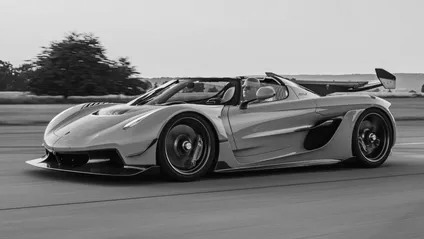

In [2]:
image = cv2.imread("car.png", cv2.IMREAD_GRAYSCALE)
cv2_imshow(image)

In [3]:
def convolution(image, kernel, strides=1):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = (image.shape[0] - kernel_height) // strides + 1
    output_width = (image.shape[1] - kernel_width) // strides + 1
    output = np.zeros((output_height, output_width))

    for i in range(1, image.shape[0] - 1, strides):
        for j in range(1, image.shape[1] - 1, strides):
            val = (
                image[i-1, j-1] * kernel[0, 0] +
                image[i-1, j]   * kernel[0, 1] +
                image[i-1, j+1] * kernel[0, 2] +
                image[i,   j-1] * kernel[1, 0] +
                image[i,   j]   * kernel[1, 1] +
                image[i,   j+1] * kernel[1, 2] +
                image[i+1, j-1] * kernel[2, 0] +
                image[i+1, j]   * kernel[2, 1] +
                image[i+1, j+1] * kernel[2, 2]
            )
            out_i = (i - 1) // strides
            out_j = (j - 1) // strides
            output[out_i, out_j] = val

    return output

In [4]:
kernel = np.array([[-1,-1,-1],[-1,8.9,-1],[-1,-1,-1]])

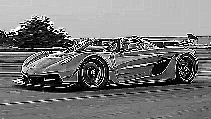

In [5]:
conv_img = convolution(image, kernel, 2)
cv2_imshow(conv_img)

In [6]:
def relu(image):
    for i in range(0, image.shape[0]):
        for j in range(0, image.shape[1]):
            if image[i, j] >= 0:
                image[i, j] = image[i, j]
            else:
                image[i, j] = 0

    return image

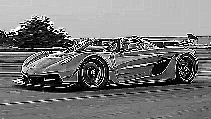

In [7]:
relu_img = relu(conv_img)
cv2_imshow(relu_img)

In [8]:
def max_pooling(image, pool_size=2, strides=1):
    image_height, image_width = image.shape

    output_height = (image_height - pool_size) // strides + 1
    output_width = (image_width - pool_size) // strides + 1
    output = np.zeros((output_height, output_width))

    for i in range(0, image_height - 1, strides):
        for j in range(0, image_width - 1, strides):

            val = image[i, j]

            if image[i, j+1] > val:
                val = image[i, j+1]

            if image[i+1, j] > val:
                val = image[i+1, j]

            if image[i+1, j+1] > val:
                val = image[i+1, j+1]

            out_i = i // strides
            out_j = j // strides

            if out_i < output_height and out_j < output_width:
                output[out_i, out_j] = val

    return output

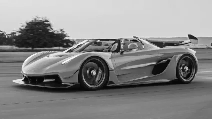

In [9]:
pool_img = max_pooling(image, 2, 2)
cv2_imshow(pool_img)

In [10]:
flat_img = pool_img.flatten()

In [11]:
print(f"""
Original Image Shape: {image.shape}\n
Convolution Image Shape: {conv_img.shape}\n
ReLU Image Shape: {relu_img.shape}\n
Max Pooling Image Shape: {pool_img.shape}\n
Flattened Image Shape: {flat_img.shape}\n
""")


Original Image Shape: (239, 424)

Convolution Image Shape: (119, 211)

ReLU Image Shape: (119, 211)

Max Pooling Image Shape: (119, 212)

Flattened Image Shape: (25228,)




In [12]:
weights = np.random.rand(flat_img.shape[0])

np.dot(flat_img, weights)

np.float64(1715142.880347229)

#### With keras

In [10]:
import kagglehub

path = kagglehub.dataset_download("cactus3/basicshapes")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'basicshapes' dataset.
Path to dataset files: /kaggle/input/basicshapes


In [3]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [12]:
data = []
labels = []

categories = ["/shapes/circles", "/shapes/squares"]

for category in categories:
    folder_path = path + category

    label = 0 if category == "/shapes/circles" else 1

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (64, 64))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        data.append(img)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Total images loaded:", len(data))

Total images loaded: 200


In [13]:
data = data / 255.0

data = data.reshape(-1, 64, 64, 1)

print("Data shape:", data.shape)

Data shape: (200, 64, 64, 1)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


In [24]:
model = Sequential()

# Convolution + ReLU
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)))
model.add(MaxPooling2D((2,2)))

# Convolution + ReLU
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Convolution + ReLU
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense with Sigmoid (Binary Classification)
model.add(Dense(1, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         4,609 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,283 (380.01 KB)

 Trainable params: 97,283 (380.01 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
train_model = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.5069 - loss: 0.6931 - val_accuracy: 0.4750 - val_loss: 0.6933
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.4938 - loss: 0.6932 - val_accuracy: 0.4750 - val_loss: 0.6933
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.5160 - loss: 0.6931 - val_accuracy: 0.4750 - val_loss: 0.6933
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - accuracy: 0.4956 - loss: 0.6932 - val_accuracy: 0.4750 - val_loss: 0.6933
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 371ms/step - accuracy: 0.4756 - loss: 0.6933 - val_accuracy: 0.4750 - val_loss: 0.6933
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - accuracy: 0.4899 - loss: 0.6932 - val_accuracy: 0.4750 - val_loss: 0.6933
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.5264 - loss: 0.6930 - val_accuracy: 0.4750 - val_loss: 0.6933
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.5186 - loss: 0.6930 - val_accuracy: 0.4750 - val_loss:

In [29]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4625 - loss: 0.6936
Test Accuracy: 0.4749999940395355
